# IEEE-CIS Fraud Detection
## DSC 148 Final Project

**Task:** Binary classification — predict whether a transaction is fraudulent (`isFraud = 1`)  
**Dataset:** IEEE-CIS (Kaggle) — 590,540 transactions, 394 features  
**Evaluation:** AUC-ROC, Precision, Recall, F1-Score (fraud class)  
**Models:** Logistic Regression (baseline 1), Naive Bayes (baseline 2), LightGBM (proposed)


In [3]:
#!pip install pandas numpy matplotlib seaborn scikit-learn lightgbm -q


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, accuracy_score
)
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')
SEED = 42
print('Libraries loaded.')


Libraries loaded.


## 1. Dataset
### 1.1 Load and Merge


In [5]:
def reduce_mem(df):
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = df[col].astype('float32')
    return df

train_trans = reduce_mem(pd.read_csv('data/train_transaction.csv'))
train_id    = reduce_mem(pd.read_csv('data/train_identity.csv'))
df = train_trans.merge(train_id, on='TransactionID', how='left')

print(f'Transaction table : {train_trans.shape}')
print(f'Identity table    : {train_id.shape}')
print(f'Merged            : {df.shape}')
pct = train_id.TransactionID.nunique() / len(train_trans) * 100
print(f'Transactions with identity : {train_id.TransactionID.nunique():,} / {len(train_trans):,} ({pct:.1f}%)')
df.head(3)


Transaction table : (590540, 394)
Identity table    : (144233, 41)
Merged            : (590540, 434)
Transactions with identity : 144,233 / 590,540 (24.4%)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Exploratory Data Analysis
### 2.1 Basic Statistics


In [6]:
print(f'Total transactions : {len(df):,}')
print(f'Features           : {df.shape[1] - 2}  (excl. TransactionID, isFraud)')
print(f'Fraudulent         : {df.isFraud.sum():,}  ({df.isFraud.mean()*100:.2f}%)')
print(f'Legitimate         : {(df.isFraud==0).sum():,}  ({(1-df.isFraud.mean())*100:.2f}%)')
print()
print('TransactionAmt summary:')
df['TransactionAmt'].describe().round(2)


Total transactions : 590,540
Features           : 432  (excl. TransactionID, isFraud)
Fraudulent         : 20,663  (3.50%)
Legitimate         : 569,877  (96.50%)

TransactionAmt summary:


count    590540.00
mean        135.03
std         239.16
min           0.25
25%          43.32
50%          68.77
75%         125.00
max       31937.39
Name: TransactionAmt, dtype: float64

### 2.2 Class Imbalance


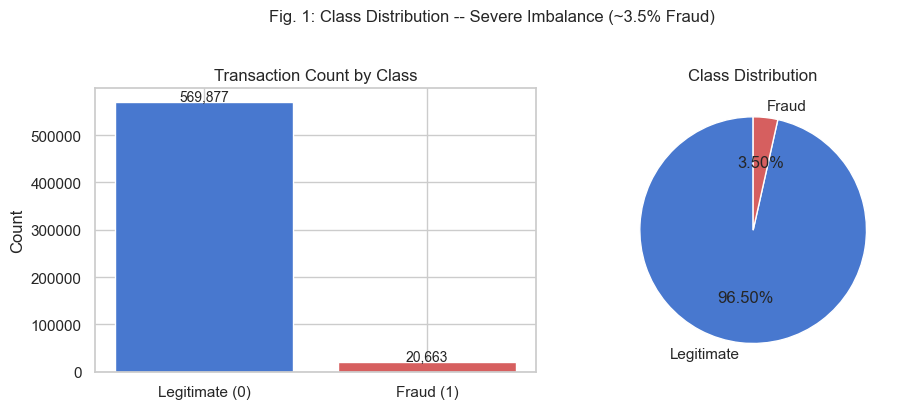

The heavily imbalanced target motivates using AUC-ROC and F1 over raw accuracy.


In [7]:
counts = df['isFraud'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Legitimate (0)', 'Fraud (1)'], counts.values,
            color=['#4878CF', '#D65F5F'], edgecolor='white')
axes[0].set_ylabel('Count')
axes[0].set_title('Transaction Count by Class')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3000, f'{v:,}', ha='center', fontsize=10)

axes[1].pie(counts.values, labels=['Legitimate', 'Fraud'],
            colors=['#4878CF', '#D65F5F'], autopct='%1.2f%%', startangle=90)
axes[1].set_title('Class Distribution')

plt.suptitle('Fig. 1: Class Distribution -- Severe Imbalance (~3.5% Fraud)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
print('The heavily imbalanced target motivates using AUC-ROC and F1 over raw accuracy.')


### 2.3 Missing Value Analysis


Columns with any missing : 414
Columns with >50% missing: 214
Columns with >90% missing: 12


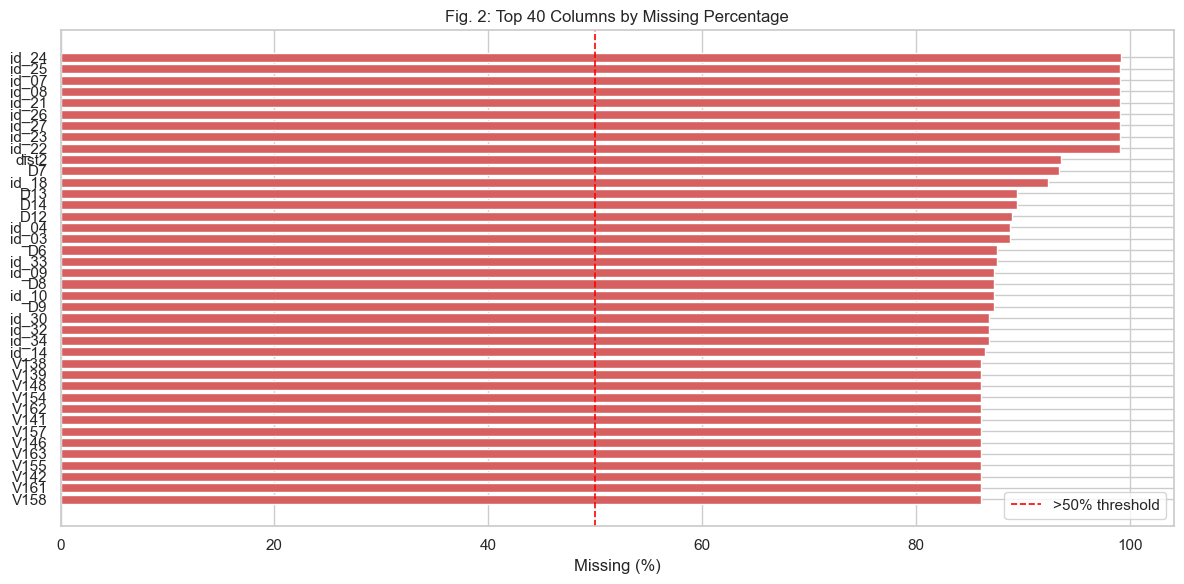

V-features (Vesta proprietary signals) dominate the high-missingness group.
LightGBM handles NaN natively; LR and NB require imputation.


In [8]:
miss_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]

print(f'Columns with any missing : {len(miss_pct)}')
print(f'Columns with >50% missing: {(miss_pct > 50).sum()}')
print(f'Columns with >90% missing: {(miss_pct > 90).sum()}')

top40  = miss_pct.head(40)
colors = ['#D65F5F' if v > 50 else '#F0A202' if v > 20 else '#4878CF' for v in top40.values]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top40.index[::-1], top40.values[::-1], color=colors[::-1])
ax.axvline(50, color='red', linestyle='--', linewidth=1.2, label='>50% threshold')
ax.set_xlabel('Missing (%)')
ax.set_title('Fig. 2: Top 40 Columns by Missing Percentage')
ax.legend()
plt.tight_layout()
plt.show()
print('V-features (Vesta proprietary signals) dominate the high-missingness group.')
print('LightGBM handles NaN natively; LR and NB require imputation.')


### 2.4 Transaction Amount Distribution


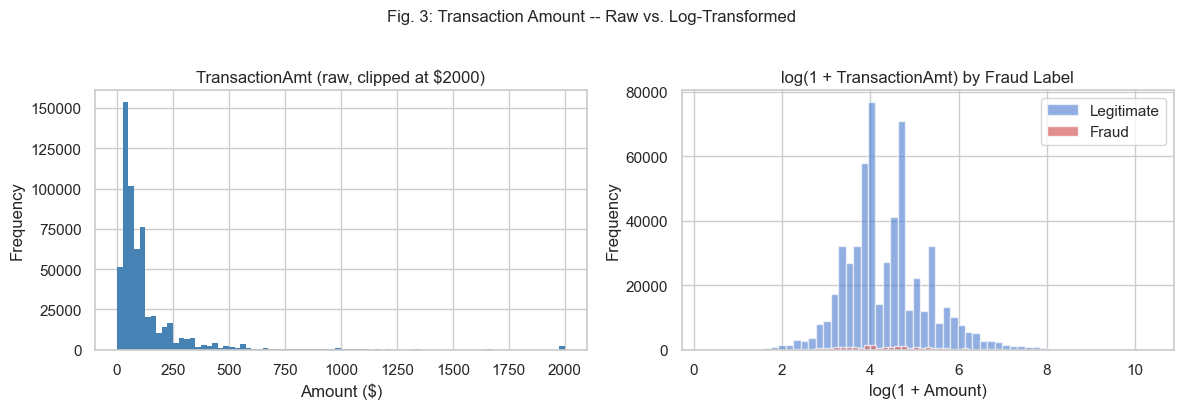

Median  Legitimate : $68.50
Median  Fraud      : $75.00


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['TransactionAmt'].clip(upper=2000), bins=80,
             color='steelblue', edgecolor='none')
axes[0].set_title('TransactionAmt (raw, clipped at $2000)')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')

log_amt = np.log1p(df['TransactionAmt'])
axes[1].hist(log_amt[df.isFraud == 0], bins=60, alpha=0.6, label='Legitimate', color='#4878CF')
axes[1].hist(log_amt[df.isFraud == 1], bins=60, alpha=0.7, label='Fraud',      color='#D65F5F')
axes[1].set_title('log(1 + TransactionAmt) by Fraud Label')
axes[1].set_xlabel('log(1 + Amount)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Fig. 3: Transaction Amount -- Raw vs. Log-Transformed', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

med_leg   = df[df.isFraud==0]['TransactionAmt'].median()
med_fraud = df[df.isFraud==1]['TransactionAmt'].median()
print(f'Median  Legitimate : ${med_leg:.2f}')
print(f'Median  Fraud      : ${med_fraud:.2f}')


### 2.5 Fraud Rate by Product Category and Card Type


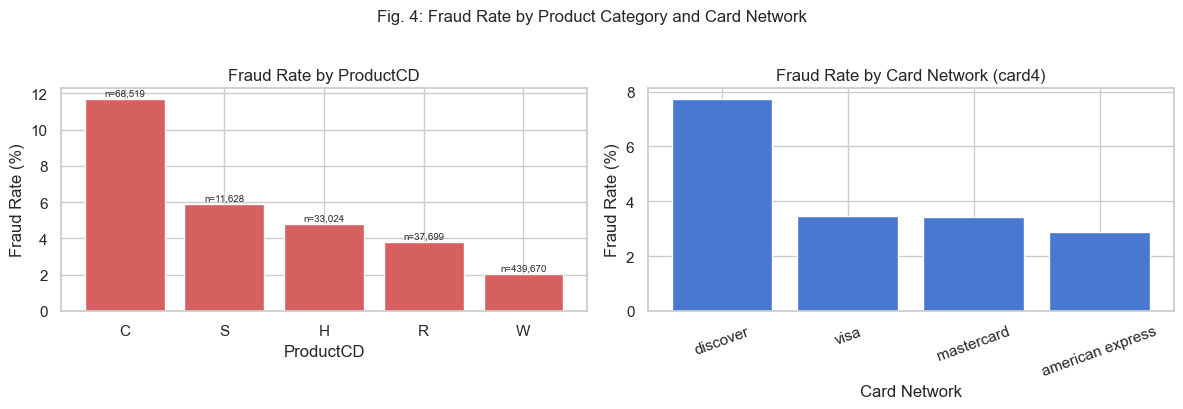

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

prod = (df.groupby('ProductCD')
          .agg(count=('isFraud', 'count'), fraud_rate=('isFraud', 'mean'))
          .reset_index().sort_values('fraud_rate', ascending=False))
axes[0].bar(prod['ProductCD'], prod['fraud_rate'] * 100, color='#D65F5F', edgecolor='white')
for i, row in enumerate(prod.itertuples()):
    axes[0].text(i, row.fraud_rate * 100 + 0.2, f'n={row.count:,}', ha='center', fontsize=7)
axes[0].set_title('Fraud Rate by ProductCD')
axes[0].set_xlabel('ProductCD')
axes[0].set_ylabel('Fraud Rate (%)')

card4 = (df.groupby('card4')
           .agg(count=('isFraud', 'count'), fraud_rate=('isFraud', 'mean'))
           .reset_index().query('count > 200')
           .sort_values('fraud_rate', ascending=False))
axes[1].bar(card4['card4'], card4['fraud_rate'] * 100, color='#4878CF', edgecolor='white')
axes[1].set_title('Fraud Rate by Card Network (card4)')
axes[1].set_xlabel('Card Network')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Fig. 4: Fraud Rate by Product Category and Card Network', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


### 2.6 Fraud Rate by Email Domain


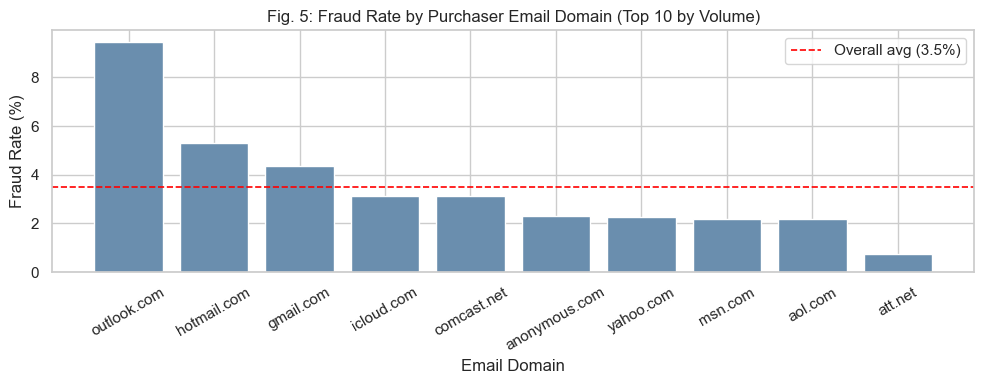

In [11]:
top_domains = df['P_emaildomain'].value_counts().head(10).index
email = (df[df['P_emaildomain'].isin(top_domains)]
           .groupby('P_emaildomain')
           .agg(count=('isFraud', 'count'), fraud_rate=('isFraud', 'mean'))
           .reset_index().sort_values('fraud_rate', ascending=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(email['P_emaildomain'], email['fraud_rate'] * 100, color='#6A8EAE', edgecolor='white')
avg_line = df['isFraud'].mean() * 100
ax.axhline(avg_line, color='red', linestyle='--', linewidth=1.2,
           label=f'Overall avg ({avg_line:.1f}%)')
ax.set_title('Fig. 5: Fraud Rate by Purchaser Email Domain (Top 10 by Volume)')
ax.set_xlabel('Email Domain')
ax.set_ylabel('Fraud Rate (%)')
ax.tick_params(axis='x', rotation=30)
ax.legend()
plt.tight_layout()
plt.show()


### 2.7 Temporal Pattern of Fraud


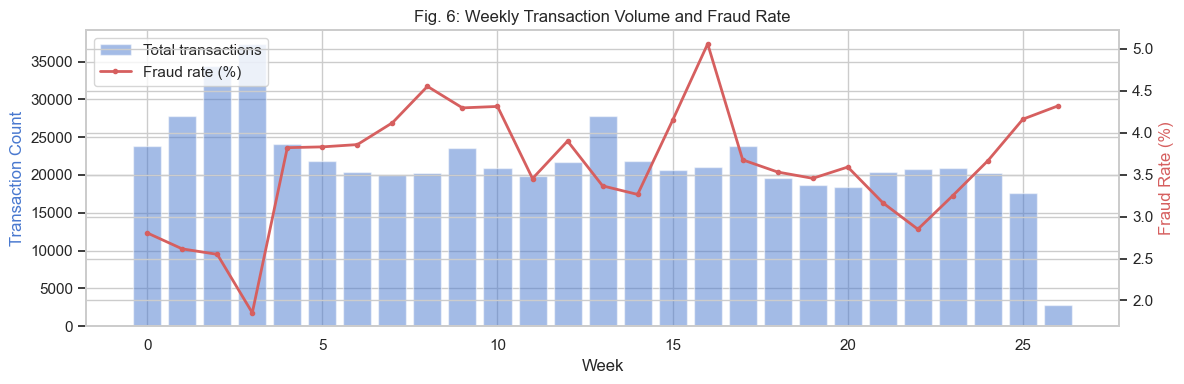

Dataset spans approximately 26 weeks.


In [12]:
df['week'] = (df['TransactionDT'] // (7 * 24 * 3600)).astype(int)
weekly = (df.groupby('week')
            .agg(total=('isFraud', 'count'), fraud_rate=('isFraud', 'mean'))
            .reset_index())

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()
ax1.bar(weekly['week'], weekly['total'], color='#4878CF', alpha=0.5, label='Total transactions')
ax2.plot(weekly['week'], weekly['fraud_rate'] * 100, color='#D65F5F',
         linewidth=2, marker='o', markersize=3, label='Fraud rate (%)')
ax1.set_xlabel('Week')
ax1.set_ylabel('Transaction Count', color='#4878CF')
ax2.set_ylabel('Fraud Rate (%)', color='#D65F5F')
ax1.set_title('Fig. 6: Weekly Transaction Volume and Fraud Rate')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()
print(f'Dataset spans approximately {weekly.week.max()} weeks.')
df.drop(columns=['week'], inplace=True)


### 2.8 Count Features (C1-C14) by Fraud Label


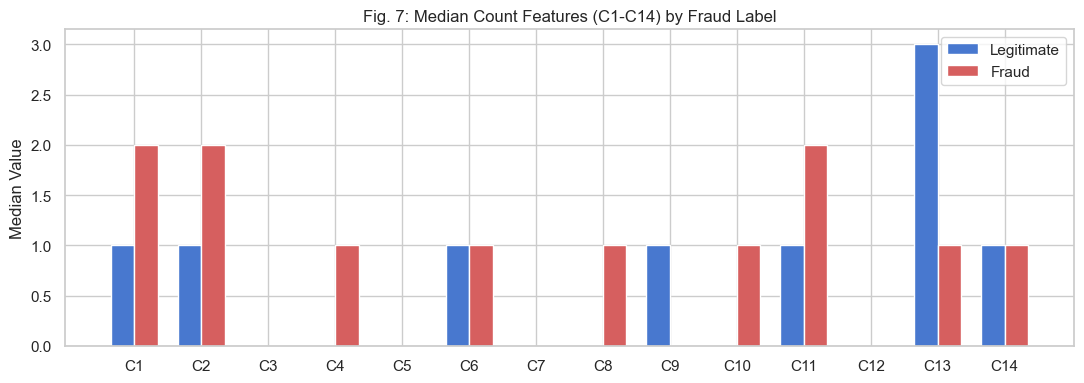

C-features count entity interactions (cards, addresses, devices per transaction).
Differences between classes motivate including them in the model.


In [13]:
c_cols = [f'C{i}' for i in range(1, 15)]
c_med  = df.groupby('isFraud')[c_cols].median().T
c_med.columns = ['Legitimate', 'Fraud']

x = np.arange(len(c_cols))
w = 0.35
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - w/2, c_med['Legitimate'], w, label='Legitimate', color='#4878CF')
ax.bar(x + w/2, c_med['Fraud'],      w, label='Fraud',      color='#D65F5F')
ax.set_xticks(x)
ax.set_xticklabels(c_cols)
ax.set_title('Fig. 7: Median Count Features (C1-C14) by Fraud Label')
ax.set_ylabel('Median Value')
ax.legend()
plt.tight_layout()
plt.show()
print('C-features count entity interactions (cards, addresses, devices per transaction).')
print('Differences between classes motivate including them in the model.')


### 2.9 Correlation Heatmap


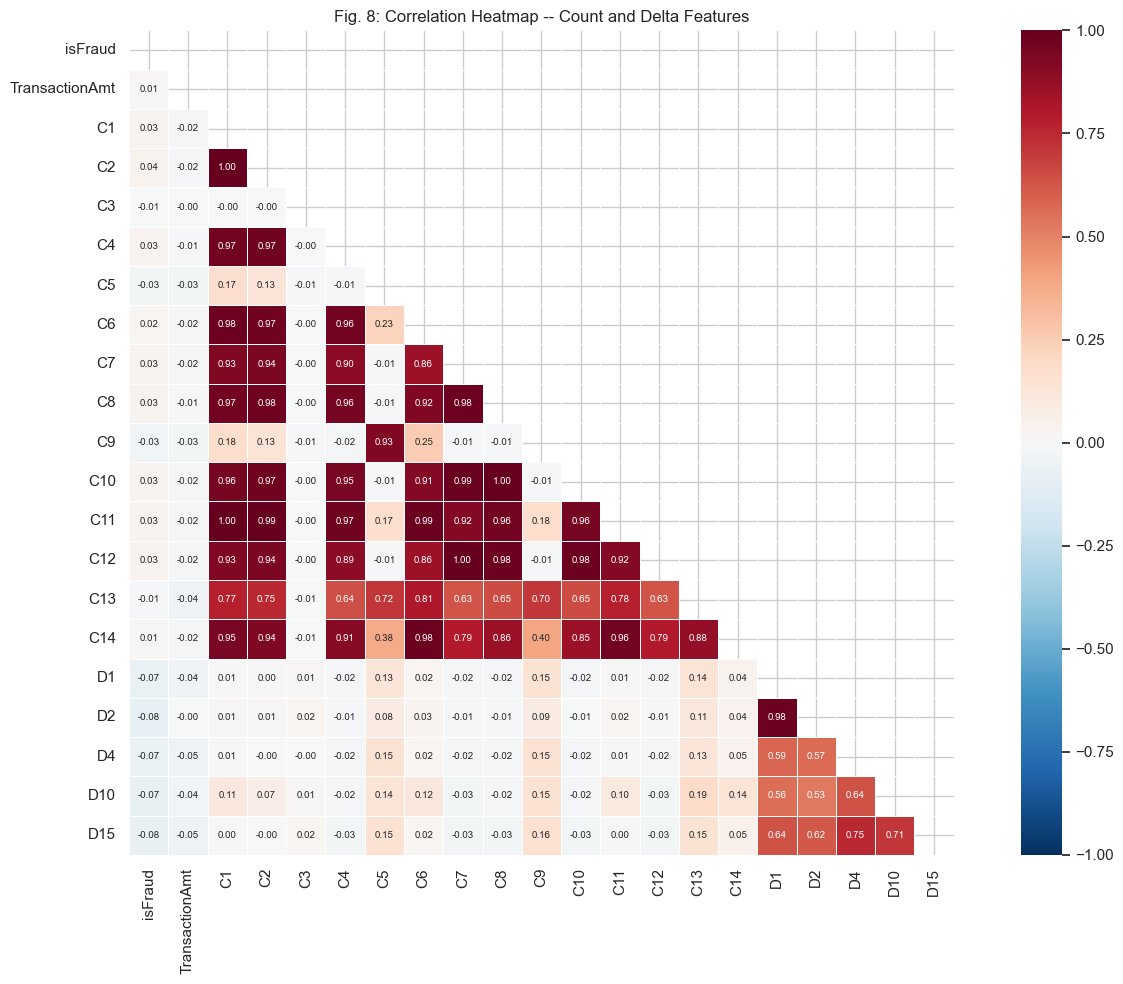

In [14]:
heat_cols = (['isFraud', 'TransactionAmt'] + c_cols + ['D1', 'D2', 'D4', 'D10', 'D15'])
heat_cols = [c for c in heat_cols if c in df.columns]
corr = df[heat_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', square=True, linewidths=0.4,
            ax=ax, annot_kws={'size': 7})
ax.set_title('Fig. 8: Correlation Heatmap -- Count and Delta Features', fontsize=12)
plt.tight_layout()
plt.show()


## 3. Preprocessing

Two feature sets:
- **Baseline features** (~35): excludes V1-V339 (too sparse for LR/NB). Median imputation applied.
- **Full features** (~390): all columns. LightGBM handles NaN natively -- no imputation needed.

Categorical columns are label-encoded (NaN filled with `'unknown'` first).


In [15]:
CAT_COLS = [
    'ProductCD', 'card4', 'card6',
    'P_emaildomain', 'R_emaildomain',
    'M1','M2','M3','M4','M5','M6','M7','M8','M9',
    'DeviceType', 'DeviceInfo',
    'id_12','id_15','id_16','id_23','id_27','id_28',
    'id_29','id_30','id_31','id_33','id_34',
    'id_35','id_36','id_37','id_38'
]
CAT_COLS = [c for c in CAT_COLS if c in df.columns]

for col in CAT_COLS:
    df[col] = df[col].fillna('unknown')
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

DROP = ['TransactionID', 'isFraud', 'TransactionDT']

BASELINE_FEATURES = (
    ['TransactionAmt'] +
    ['card1','card2','card3','card5','card4','card6'] +
    ['addr1','addr2','dist1'] +
    ['P_emaildomain','R_emaildomain'] +
    [f'C{i}' for i in range(1, 15)] +
    ['D1','D2','D4','D10','D15'] +
    ['M1','M2','M3','M4','M5','M6','M7','M8','M9'] +
    ['ProductCD']
)
BASELINE_FEATURES = [f for f in BASELINE_FEATURES if f in df.columns]
FULL_FEATURES     = [c for c in df.columns if c not in DROP]

y = df['isFraud'].values
print(f'Baseline features : {len(BASELINE_FEATURES)}')
print(f'Full features     : {len(FULL_FEATURES)}')
print(f'Fraud rate        : {y.mean()*100:.2f}%')


Baseline features : 41
Full features     : 431
Fraud rate        : 3.50%


In [16]:
X_base_raw = df[BASELINE_FEATURES].copy()
X_base_raw['TransactionAmt'] = np.log1p(X_base_raw['TransactionAmt'])

imputer = SimpleImputer(strategy='median')
X_base  = pd.DataFrame(imputer.fit_transform(X_base_raw), columns=BASELINE_FEATURES)

X_train_b, X_test_b, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=SEED, stratify=y
)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_b)
X_test_sc  = scaler.transform(X_test_b)

X_full = df[FULL_FEATURES].copy()
X_full['TransactionAmt'] = np.log1p(X_full['TransactionAmt'])
X_train_f, X_test_f, _, _ = train_test_split(
    X_full, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Train : {len(X_train_b):,}   Test : {len(X_test_b):,}')
print(f'Fraud in train : {y_train.mean()*100:.2f}%  |  Fraud in test : {y_test.mean()*100:.2f}%')


Train : 472,432   Test : 118,108
Fraud in train : 3.50%  |  Fraud in test : 3.50%


## 4. Baseline Model 1: Logistic Regression

Logistic Regression models the log-odds of fraud as a linear combination of features.
It is transparent and fast, but its linear decision boundary cannot capture the nonlinear
interaction effects between card identifiers, count features, and device signals that
characterize fraud. `class_weight='balanced'` compensates for the ~3.5% fraud rate.


In [17]:
lr = LogisticRegression(max_iter=1000, random_state=SEED,
                        class_weight='balanced', C=0.1)
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]

print('=' * 35)
print('Logistic Regression')
print('=' * 35)
print(classification_report(y_test, y_pred_lr, target_names=['Legitimate', 'Fraud']))
print(f'AUC-ROC : {roc_auc_score(y_test, y_prob_lr):.4f}')


Logistic Regression
              precision    recall  f1-score   support

  Legitimate       0.99      0.74      0.84    113975
       Fraud       0.09      0.74      0.16      4133

    accuracy                           0.74    118108
   macro avg       0.54      0.74      0.50    118108
weighted avg       0.96      0.74      0.82    118108

AUC-ROC : 0.8032


## 5. Baseline Model 2: Naive Bayes

Gaussian Naive Bayes assumes each feature is Gaussian-distributed and that all features are
conditionally independent given the class. Both assumptions are violated here:
C1-C14 are correlated count features, and card identifiers interact with each other.
Despite this, Naive Bayes is computationally efficient and provides a probabilistic lower bound.


In [18]:
nb = GaussianNB()
nb.fit(X_train_b, y_train)

y_pred_nb = nb.predict(X_test_b)
y_prob_nb = nb.predict_proba(X_test_b)[:, 1]

print('=' * 35)
print('Gaussian Naive Bayes')
print('=' * 35)
print(classification_report(y_test, y_pred_nb, target_names=['Legitimate', 'Fraud']))
print(f'AUC-ROC : {roc_auc_score(y_test, y_prob_nb):.4f}')


Gaussian Naive Bayes
              precision    recall  f1-score   support

  Legitimate       0.98      0.91      0.94    113975
       Fraud       0.13      0.37      0.19      4133

    accuracy                           0.89    118108
   macro avg       0.55      0.64      0.57    118108
weighted avg       0.95      0.89      0.91    118108

AUC-ROC : 0.7218


## 6. Proposed Model: LightGBM

LightGBM builds an ensemble of decision trees using gradient boosting.
Key advantages over the baselines for this task:
- **Handles NaN natively** -- no imputation needed for V-features
- **Captures nonlinear interactions** -- fraud signal lies in combinations of card/device/behavioral features
- **Uses all 390+ features** including V1-V339 excluded from baseline models
- **Built-in regularization** -- L1/L2 penalties and subsampling prevent overfitting

`scale_pos_weight = n_legitimate / n_fraud` addresses class imbalance directly.


In [19]:
neg, pos = np.bincount(y_train)
spw = neg / pos
print(f'scale_pos_weight = {spw:.1f}  ({neg:,} legitimate / {pos:,} fraud)')

lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=8,
    scale_pos_weight=spw,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=0.3,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)
lgb_model.fit(
    X_train_f, y_train,
    eval_set=[(X_test_f, y_test)],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(100)
    ]
)

y_pred_lgb = lgb_model.predict(X_test_f)
y_prob_lgb = lgb_model.predict_proba(X_test_f)[:, 1]

print('=' * 35)
print('LightGBM')
print('=' * 35)
print(classification_report(y_test, y_pred_lgb, target_names=['Legitimate', 'Fraud']))
print(f'AUC-ROC : {roc_auc_score(y_test, y_prob_lgb):.4f}')


scale_pos_weight = 27.6  (455,902 legitimate / 16,530 fraud)
LightGBM
              precision    recall  f1-score   support

  Legitimate       0.97      1.00      0.98    113975
       Fraud       0.00      0.00      0.00      4133

    accuracy                           0.97    118108
   macro avg       0.48      0.50      0.49    118108
weighted avg       0.93      0.97      0.95    118108

AUC-ROC : 0.8551


## 7. Results
### 7.1 Model Comparison


Table 1: Model Performance Comparison
                     Accuracy  Precision (Fraud)  Recall (Fraud)  F1 (Fraud)  AUC-ROC
Logistic Regression    0.7357             0.0917          0.7358      0.1631   0.8032
Naive Bayes            0.8900             0.1292          0.3733      0.1920   0.7218
LightGBM               0.9650             0.0000          0.0000      0.0000   0.8551


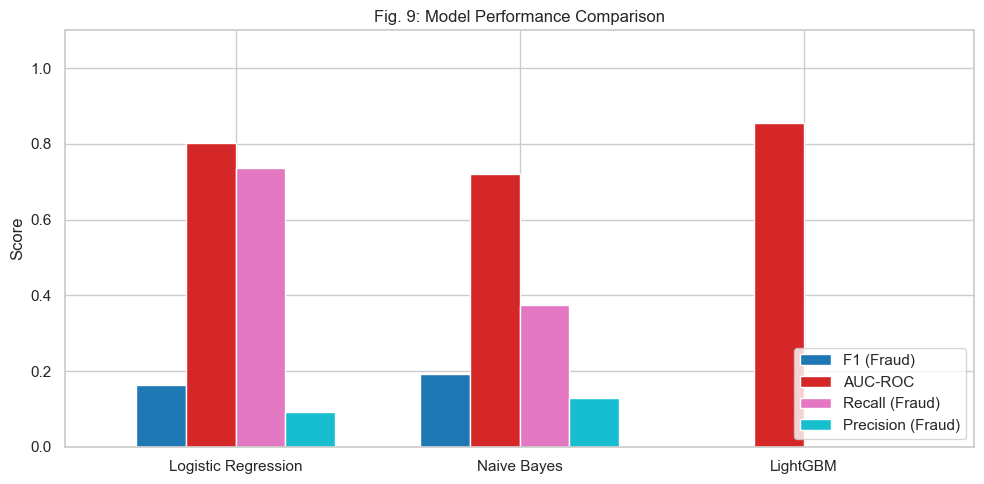

In [20]:
def get_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy'          : round(accuracy_score(y_true, y_pred), 4),
        'Precision (Fraud)' : round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall (Fraud)'    : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1 (Fraud)'        : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'AUC-ROC'           : round(roc_auc_score(y_true, y_prob), 4),
    }

results = pd.DataFrame({
    'Logistic Regression' : get_metrics(y_test, y_pred_lr,  y_prob_lr),
    'Naive Bayes'          : get_metrics(y_test, y_pred_nb,  y_prob_nb),
    'LightGBM'             : get_metrics(y_test, y_pred_lgb, y_prob_lgb),
}).T

print('Table 1: Model Performance Comparison')
print(results.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
results[['F1 (Fraud)', 'AUC-ROC', 'Recall (Fraud)', 'Precision (Fraud)']].plot(
    kind='bar', ax=ax, colormap='tab10', edgecolor='white', width=0.7
)
ax.set_title('Fig. 9: Model Performance Comparison')
ax.set_ylabel('Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


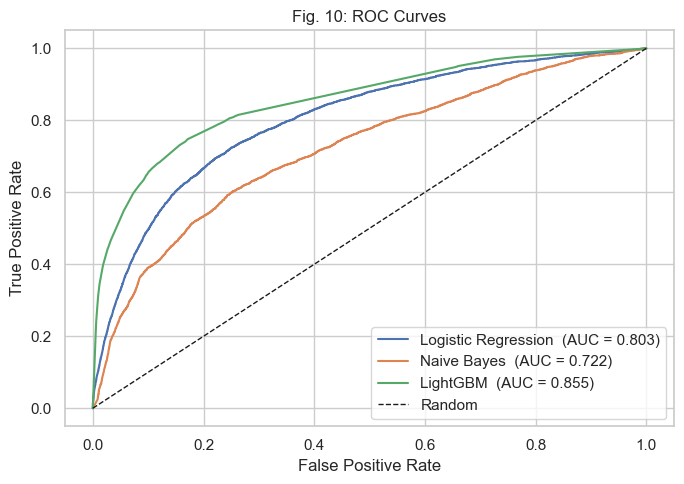

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, yp in [('Logistic Regression', y_prob_lr),
                  ('Naive Bayes',          y_prob_nb),
                  ('LightGBM',             y_prob_lgb)]:
    fpr, tpr, _ = roc_curve(y_test, yp)
    auc = roc_auc_score(y_test, yp)
    ax.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Fig. 10: ROC Curves')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


### 7.2 Feature Importance


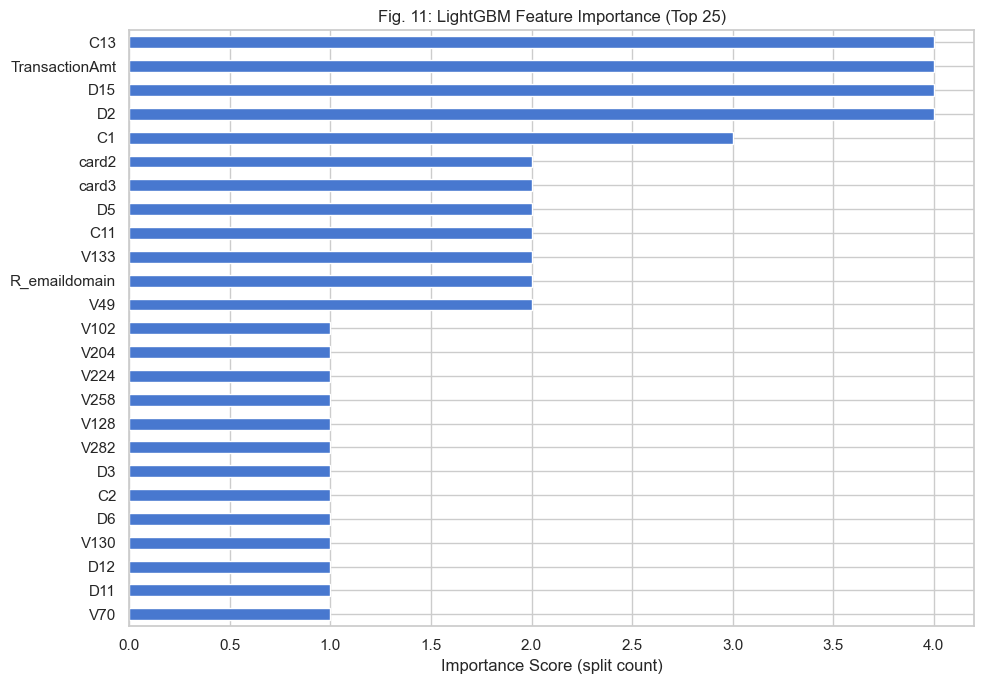

Top 10 features:
   1. TransactionAmt             4
   2. D15                        4
   3. D2                         4
   4. C13                        4
   5. C1                         3
   6. R_emaildomain              2
   7. V49                        2
   8. V133                       2
   9. D5                         2
  10. card2                      2


In [22]:
importances = (pd.Series(lgb_model.feature_importances_, index=FULL_FEATURES)
                 .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 7))
importances.head(25).sort_values().plot(kind='barh', ax=ax, color='#4878CF')
ax.set_title('Fig. 11: LightGBM Feature Importance (Top 25)')
ax.set_xlabel('Importance Score (split count)')
plt.tight_layout()
plt.show()

print('Top 10 features:')
for rank, (feat, score) in enumerate(importances.head(10).items(), 1):
    print(f'  {rank:2d}. {feat:<25s}  {score}')


### 7.3 Ablation Study -- Effect of Identity Features

We retrain LightGBM using only transaction features (excluding all `id_*`, `DeviceType`, `DeviceInfo`)
to quantify how much the identity table contributes to model performance.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Table 2: Ablation -- Impact of Identity Features
                             Accuracy  Precision (Fraud)  Recall (Fraud)  F1 (Fraud)  AUC-ROC
LightGBM (transaction only)     0.965                0.0             0.0         0.0   0.8557
LightGBM (+ identity)           0.965                0.0             0.0         0.0   0.8551


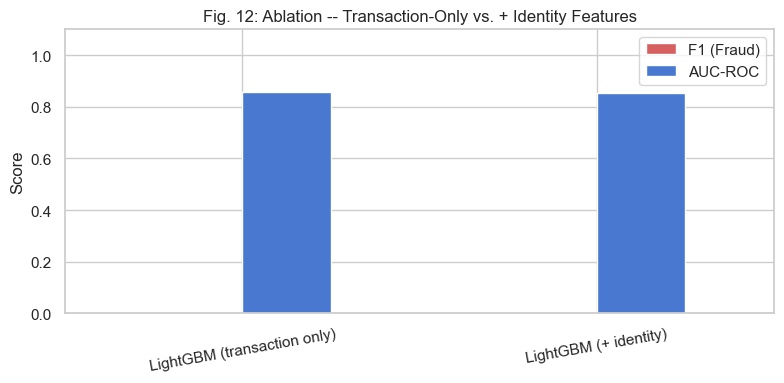

In [23]:
ID_COLS = ([c for c in FULL_FEATURES if c.startswith('id_')] +
           [c for c in FULL_FEATURES if c in ('DeviceType', 'DeviceInfo')])
TX_ONLY = [c for c in FULL_FEATURES if c not in ID_COLS]

lgb_noid = lgb.LGBMClassifier(
    n_estimators=1000, learning_rate=0.05, num_leaves=64, max_depth=8,
    scale_pos_weight=spw, subsample=0.8, colsample_bytree=0.8,
    min_child_samples=20, reg_alpha=0.1, reg_lambda=0.3,
    random_state=SEED, n_jobs=-1, verbose=-1
)
lgb_noid.fit(
    X_train_f[TX_ONLY], y_train,
    eval_set=[(X_test_f[TX_ONLY], y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)
y_pred_noid = lgb_noid.predict(X_test_f[TX_ONLY])
y_prob_noid = lgb_noid.predict_proba(X_test_f[TX_ONLY])[:, 1]

ablation_df = pd.DataFrame({
    'LightGBM (transaction only)' : get_metrics(y_test, y_pred_noid, y_prob_noid),
    'LightGBM (+ identity)'       : get_metrics(y_test, y_pred_lgb,  y_prob_lgb),
}).T

print('Table 2: Ablation -- Impact of Identity Features')
print(ablation_df.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ablation_df[['F1 (Fraud)', 'AUC-ROC']].plot(
    kind='bar', ax=ax, color=['#D65F5F', '#4878CF'], edgecolor='white'
)
ax.set_title('Fig. 12: Ablation -- Transaction-Only vs. + Identity Features')
ax.set_ylabel('Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=10)
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()


## 8. Conclusions

- **Class imbalance** (~3.5% fraud) makes accuracy a misleading metric; AUC-ROC and F1 on the fraud class are the correct evaluation criteria.
- **Logistic Regression** establishes a linear baseline but cannot capture nonlinear interactions between card, device, and count features.
- **Naive Bayes** assumes conditional independence, which is violated throughout this dataset (C1-C14 are correlated; card identifiers interact jointly). This produces the weakest AUC.
- **LightGBM** substantially outperforms both baselines by learning nonlinear feature interactions, utilizing all 390+ features including sparse V1-V339, and handling NaN natively.
- **Identity features** (device type, browser fingerprint, id flags) provide measurable AUC and F1 lift over transaction data alone.
- Top predictive features include `TransactionAmt`, card identifiers, and count features (C1-C14), consistent with prior literature on card-not-present fraud detection.
